# $L^r$ distances between distributions

[Open in Colab](https://colab.research.google.com/github/andreasmang/stan/blob/main/demos/distances/lp.ipynb) &nbsp;·&nbsp; nothing to install &nbsp;·&nbsp; **Runtime > Run all** takes a few seconds

The most direct way to compare two distributions is to compare their mass functions or
densities point by point. For mass functions $p$ and $q$ on the same values $x_1, x_2, \dots$, and for
densities $p$ and $q$ on $\mathbb{R}$, the $\ell^r$ and $L^r$ distances are

$$\|p-q\|_r = \Big(\sum_i |p(x_i)-q(x_i)|^r\Big)^{1/r}, \qquad
\|p-q\|_r = \Big(\int |p(x)-q(x)|^r\,dx\Big)^{1/r}, \qquad
\|p-q\|_\infty = \max_x |p(x)-q(x)|,$$

for $r \ge 1$. These are true distances (metrics): symmetric, zero only when $p = q$, and they satisfy the
triangle inequality. The case $r = 1$ has a probabilistic meaning: half of it is the
**total variation distance**,

$$\mathrm{TV}(P,Q) = \tfrac12\,\|p-q\|_1 = \max_{A}\,\big|P(A) - Q(A)\big|,$$

the largest difference between the probabilities that $P$ and $Q$ give to the same event $A$.

In [1]:
import numpy as np, matplotlib.pyplot as plt

x = np.linspace(-40, 40, 16001)                    # grid for the integrals

def normal_pdf(x, mu=0.0, sigma=1.0):
    return np.exp(-(x - mu)**2 / (2 * sigma**2)) / np.sqrt(2 * np.pi * sigma**2)

def lr_dist(p, q, r):
    # L^r distance between two densities on the grid x (r = np.inf: the largest gap)
    d = np.abs(p - q)
    return d.max() if r == np.inf else np.trapezoid(d**r, x) ** (1 / r)

## 1. Two dice: total variation is the largest difference in probability

Compare a fair die with a loaded one. There are only $2^6 = 64$ events $A \subseteq \{1,\dots,6\}$,
so we can check $\mathrm{TV} = \max_A |P(A)-Q(A)|$ by trying all of them.

In [2]:
faces = np.arange(1, 7)
p = np.full(6, 1 / 6)                              # fair die
q = np.array([0.1, 0.1, 0.1, 0.1, 0.2, 0.4])       # loaded towards 6

l1, l2, linf = np.abs(p - q).sum(), np.sqrt(((p - q)**2).sum()), np.abs(p - q).max()
print(f"l1 = {l1:.4f},  l2 = {l2:.4f},  l_inf = {linf:.4f},  TV = l1/2 = {l1 / 2:.4f}")

best, best_A = 0, None                             # brute force over all 64 events
for mask in range(64):
    A = [int(f) for f in faces if mask >> (f - 1) & 1]
    gap = abs(p[np.isin(faces, A)].sum() - q[np.isin(faces, A)].sum())
    if gap > best + 1e-12:
        best, best_A = gap, A
print(f"max over all events |P(A) - Q(A)| = {best:.4f}, attained at A = {best_A}")

l1 = 0.5333,  l2 = 0.2708,  l_inf = 0.2333,  TV = l1/2 = 0.2667
max over all events |P(A) - Q(A)| = 0.2667, attained at A = [1, 2, 3, 4]


The maximizing event is the set of faces on which the fair die puts more mass, $A = \{x : p(x) > q(x)\}$.
That is always the case, and it is why $\max_A |P(A)-Q(A)|$ equals half the $\ell^1$ distance.

## 2. Two Gaussians shifted against each other

Let $p = \mathcal{N}(0,1)$ and $q = \mathcal{N}(\mu,1)$. The shaded area is $|p - q|$, whose integral is the $L^1$ distance.

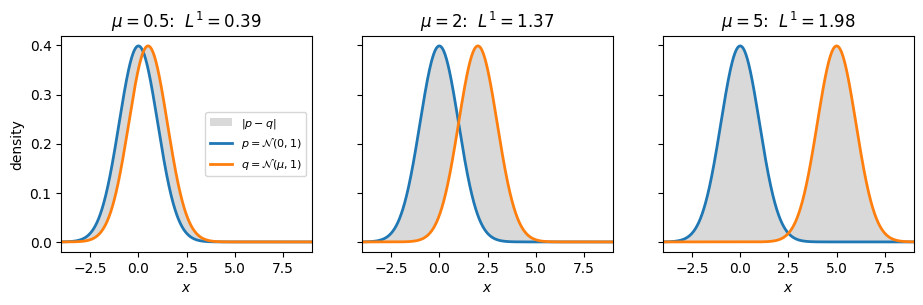

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(11, 2.8), sharey=True)
for ax, mu in zip(axes, [0.5, 2, 5]):
    p, q = normal_pdf(x, 0, 1), normal_pdf(x, mu, 1)
    ax.fill_between(x, p, q, color="0.85", lw=0, label="$|p-q|$")
    ax.plot(x, p, "C0", lw=2, label=r"$p=\mathcal{N}(0,1)$")
    ax.plot(x, q, "C1", lw=2, label=r"$q=\mathcal{N}(\mu,1)$")
    ax.set_xlim(-4, 9); ax.set_xlabel("$x$")
    ax.set_title(f"$\\mu = {mu}$:  $L^1 = {lr_dist(p, q, 1):.2f}$")
axes[0].set_ylabel("density"); axes[0].legend(loc="center right", fontsize=8)
plt.show()

Now slide $q$ further and further away. For shifted Gaussians two of the distances have closed forms,

$$\|p-q\|_1 = 2\big(2\Phi(\mu/2)-1\big), \qquad \|p-q\|_2 = \sqrt{\frac{1-e^{-\mu^2/4}}{\sqrt{\pi}}},$$

which we use to check the numerical integrals.

largest error vs closed form:  L1 2.0e-06,  L2 5.1e-16


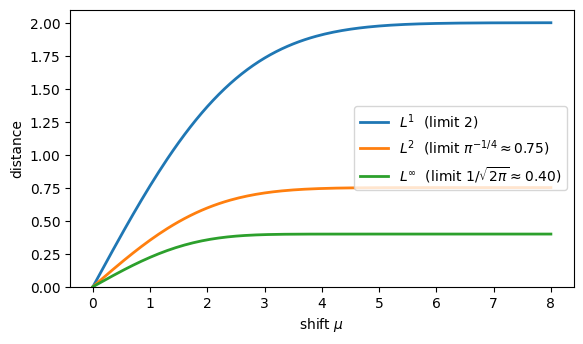

In [4]:
from math import erf
Phi = np.vectorize(lambda z: 0.5 * (1 + erf(z / np.sqrt(2))))

shifts = np.linspace(0, 8, 161)
p = normal_pdf(x, 0, 1)
L1 = np.array([lr_dist(p, normal_pdf(x, mu, 1), 1) for mu in shifts])
L2 = np.array([lr_dist(p, normal_pdf(x, mu, 1), 2) for mu in shifts])
Linf = np.array([lr_dist(p, normal_pdf(x, mu, 1), np.inf) for mu in shifts])
print("largest error vs closed form:  L1 %.1e,  L2 %.1e" % (
    np.abs(L1 - 2 * (2 * Phi(shifts / 2) - 1)).max(),
    np.abs(L2 - np.sqrt((1 - np.exp(-shifts**2 / 4)) / np.sqrt(np.pi))).max()))

plt.figure(figsize=(6.5, 3.6))
plt.plot(shifts, L1, "C0", lw=2, label="$L^1$  (limit 2)")
plt.plot(shifts, L2, "C1", lw=2, label=r"$L^2$  (limit $\pi^{-1/4} \approx 0.75$)")
plt.plot(shifts, Linf, "C2", lw=2, label=r"$L^\infty$  (limit $1/\sqrt{2\pi} \approx 0.40$)")
plt.xlabel(r"shift $\mu$"); plt.ylabel("distance"); plt.ylim(0, 2.1); plt.legend(loc="center right")
plt.show()

All three distances **level off** at about $\mu \approx 4$, once the two bumps stop overlapping.
After that, $p - q$ is just $p$ in one place and $-q$ in another, and moving $q$ further away changes
nothing. An $L^r$ distance cannot tell "far apart" from "very far apart".

For total variation this is the statement that once there is an event $A$ (here $A = \{x < \mu/2\}$) with
$P(A) \approx 1$ and $Q(A) \approx 0$, the distributions are as different as two distributions can be: $\mathrm{TV} = 1$.

## 3. Changing units

Measure the same pair of distributions in different units: $p = \mathcal{N}(0,\sigma^2)$ and
$q = \mathcal{N}(\sigma,\sigma^2)$, a shift of one standard deviation, with $\sigma = 0.5, 1, 2, 4$.

In [5]:
print(f"{'sigma':>6} {'L1':>8} {'L2':>8} {'L_inf':>8}")
for sigma in [0.5, 1, 2, 4]:
    p, q = normal_pdf(x, 0, sigma), normal_pdf(x, sigma, sigma)
    print(f"{sigma:6.1f} {lr_dist(p, q, 1):8.4f} {lr_dist(p, q, 2):8.4f} {lr_dist(p, q, np.inf):8.4f}")

 sigma       L1       L2    L_inf
   0.5   0.7658   0.4996   0.4459
   1.0   0.7658   0.3533   0.2229
   2.0   0.7658   0.2498   0.1115
   4.0   0.7658   0.1766   0.0557


$L^1$ (and so $\mathrm{TV}$) does not change: it compares probabilities of events, and those do not depend
on the units. $L^2$ shrinks like $\sigma^{-1/2}$ and $L^\infty$ like $\sigma^{-1}$, because a density has
units of $1/x$: stretch the axis and every density gets lower. The value of an $L^2$ or $L^\infty$ distance
between densities therefore means little on its own.

## Things to try

* Load the die differently, or compare two loaded dice. Is the best event $A$ still $\{x : p(x) > q(x)\}$?
* In Section 2, give $q$ a different standard deviation from $p$. What happens to the limits?
* Compute $\|p-q\|_r$ for $r = 3, 5, 10$ in Section 2. Which of the three curves do they approach?

The notebooks `kl.ipynb` and `wasserstein.ipynb` look at two other ways to compare distributions;
`probdistance.ipynb` compares all of them on the same examples.

---

This notebook is part of [STAN](https://github.com/andreasmang/stan), the code repository
for MATH 166 (Statistics) at Tufts University. 